In [3]:
import numpy as np
import random

import importlib
from pathlib import Path
import os

from backbone import sampler, draw, convolution

importlib.reload(sampler)
importlib.reload(draw)
importlib.reload(convolution)

from matplotlib import pyplot as plt

import torch
import torch.nn as nn

In [ ]:
kernel_tensor_1, angles = convolution.make_gabor_kernels(ksize=7, sigma=2, lam=4)
kernel_tensor_2, _ = convolution.make_gabor_kernels(ksize=13, sigma=3, lam=7)
kernel_tensor_3, _ = convolution.make_gabor_kernels(ksize=31, sigma=5, lam=15)
kernel_tensor_4, _ = convolution.make_gabor_kernels(ksize=51, sigma=10, lam=25)


In [ ]:
outdir = Path(os.getcwd()) / 'outputs'
os.makedirs(outdir, exist_ok=True)

#Ps = np.random.uniform(size=(4,2))
#Ps = np.vstack([[0.2,0], Ps, [0.8,1]])
#Ps = np.array([[0.,0.], [0.1,0.9], [0.9,0.1], [1.,1.]])
#Ps = np.array([[0.,0.], [1.,1.]])

radius = 0.02
thresh = 1e-3

%time C, H = sampler.draw_positions(radius, sampler.bezier_curve(Ps), thresh=thresh)
%time D, _ = sampler.draw_positions(radius, sampler.box(), exclusions=C, thresh=thresh)

CPU times: user 3.42 s, sys: 45.8 ms, total: 3.47 s
Wall time: 3.47 s
CPU times: user 18 s, sys: 102 ms, total: 18.1 s
Wall time: 18.3 s


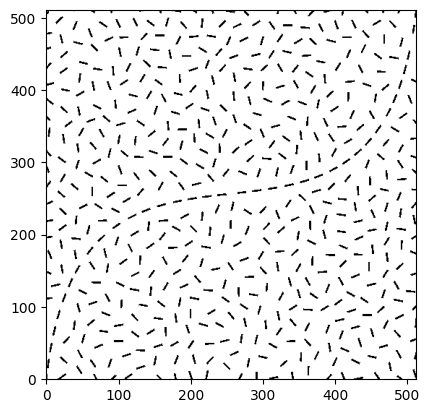

In [ ]:
# Define the patch function

l=0.025
w=0.005
pfunc = lambda z,h: draw.segment(z, h, l, w)

N = 512
If, Tf = draw.generate_image(C, H, N=N, pfunc=pfunc)
Ig, Tg = draw.generate_image(D, N=N, pfunc=pfunc)

I = If + Ig

#image = torch.tensor(Ig)
#image_tensor = image.unsqueeze(0).unsqueeze(0)

#image_tensor = image_tensor.to(torch.float32)
kernel_tensor_1 = kernel_tensor_1.to(torch.float32)
kernel_tensor_2 = kernel_tensor_2.to(torch.float32)
kernel_tensor_3 = kernel_tensor_3.to(torch.float32)
kernel_tensor_4 = kernel_tensor_4.to(torch.float32)
plt.imshow(I, aspect='equal',origin= "lower", cmap='binary')

In [ ]:
for i in range(50 ):

    # --- Convert Ig to torch tensor ---
    img_np = Ig
    img_tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    # --- First convolution ---
    conv1 = nn.functional.conv2d(
        img_tensor,
        kernel_tensor_2,
        stride=1,
        padding=3
    )

    # --- Second convolution ---
    conv2 = nn.functional.conv2d(
        conv1,
        kernel_tensor_3,
        stride=1,
        padding=15,
        groups=20
    )

        # --- Third convolution ---
    conv3 = nn.functional.conv2d(
        conv2,
        kernel_tensor_4,
        stride=1,
        padding=15,
        groups=20
    )

    # --- Compute metrics of current Ig ---
    curr_mean = (conv3**2).mean(dim=[2, 3]).sum().item()
    curr_var = conv3.var(dim=[2, 3], unbiased=False).sum().item()

    # --- Build updated candidate image ---
    updated_img = img_np.copy()
    cluster_list = convolution.clusters(conv2)

    indices = random.sample(range(26), 13)
    
    for j in indices:
        val, ch_main, px, py = cluster_list[j]

        ch_weak, weak_val = convolution.weakest_channel(conv2, px, py)
        cx, cy = convolution.find_closest(img_np, px, py)
        connected = convolution.find_connected(img_np, cx, cy)
        outline = convolution.bounding_square(connected)
        x0, y0 = outline[0]
        x1, y1 = outline[1]
        side = outline[2]

        if x0 >= 0 and y0 >= 0 and x1 < 512 and y1 < 512:
            print((x0, x1, y0, y1))
            angle = angles[ch_weak] + random.uniform(-1, 1) * 0.1
            patch = convolution.draw_segment(angle, side)
            updated_img[y0:y1, x0:x1] = patch

    # --- Recompute conv2d on the candidate image ---
    cand_tensor = torch.tensor(updated_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    
    cand_conv1 = nn.functional.conv2d(
        cand_tensor, kernel_tensor_2,
        stride=1, padding=3
    )

    cand_conv2 = nn.functional.conv2d(
        cand_conv1, kernel_tensor_3,
        stride=1, padding=15,
        groups=20
    )
    cand_conv3 = nn.functional.conv2d(
        cand_conv2, kernel_tensor_4,
        stride=1, padding=15,
        groups=20
    )
    # Metrics of candidate image
    cand_mean = (cand_conv3**2).mean(dim=[2, 3]).sum().item()
    cand_var = cand_conv3.var(dim=[2, 3], unbiased=False).sum().item()

    # --- UPDATE ONLY IF IMPROVED ---
    if cand_mean < curr_mean and cand_var < curr_var:
        Ig = updated_img
        print(f"Iter {i+1}: UPDATE | mean {(curr_mean/6):.3f} → {(cand_mean/6):.3f}, var {(curr_var/6):.3f} → {(cand_var/6):.3f}")
    else:
        # No update, but NO FREEZE — next iteration still proceeds
        print(f"Iter {i+1}: NO UPDATE | mean={(curr_mean/6):.3f}, var={(curr_var/6):.3f}")


(205, 220, 286, 301)
(169, 183, 276, 290)
(76, 92, 145, 161)
(231, 245, 445, 459)
(103, 119, 24, 40)
(231, 245, 445, 459)
(136, 151, 176, 191)
(365, 381, 327, 343)
(239, 255, 44, 60)
(463, 479, 160, 176)
(225, 240, 349, 364)
(456, 470, 88, 102)
(344, 360, 329, 345)
Iter 1: UPDATE | mean 1135259136.000 → 1132420181.333, var 1135234048.000 → 1132395349.333
(366, 382, 251, 267)
(172, 188, 18, 34)
(241, 255, 278, 292)
(57, 71, 315, 329)
(120, 136, 299, 315)
(196, 212, 19, 35)
(379, 394, 347, 362)
(114, 130, 115, 131)
(414, 429, 109, 124)
(275, 289, 297, 311)
(435, 449, 470, 484)
(462, 476, 396, 410)
(160, 176, 299, 315)
Iter 2: UPDATE | mean 1132420181.333 → 1128731477.333, var 1132395349.333 → 1128706730.667
(481, 496, 78, 93)
(436, 452, 80, 96)
(225, 239, 349, 363)
(274, 289, 296, 311)
(274, 289, 296, 311)
(170, 185, 41, 56)
(205, 219, 286, 300)
(53, 68, 471, 486)
(222, 238, 405, 421)
(352, 368, 287, 303)
(295, 308, 423, 436)
(378, 393, 90, 105)
(188, 203, 61, 76)
Iter 3: UPDATE | mean 1

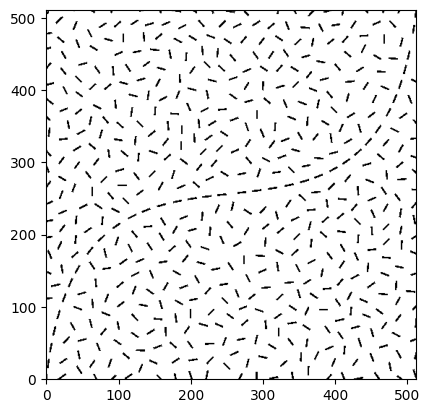

In [ ]:
Iopt = If + Ig

plt.imshow(Iopt, aspect='equal',origin= "lower", cmap='binary')

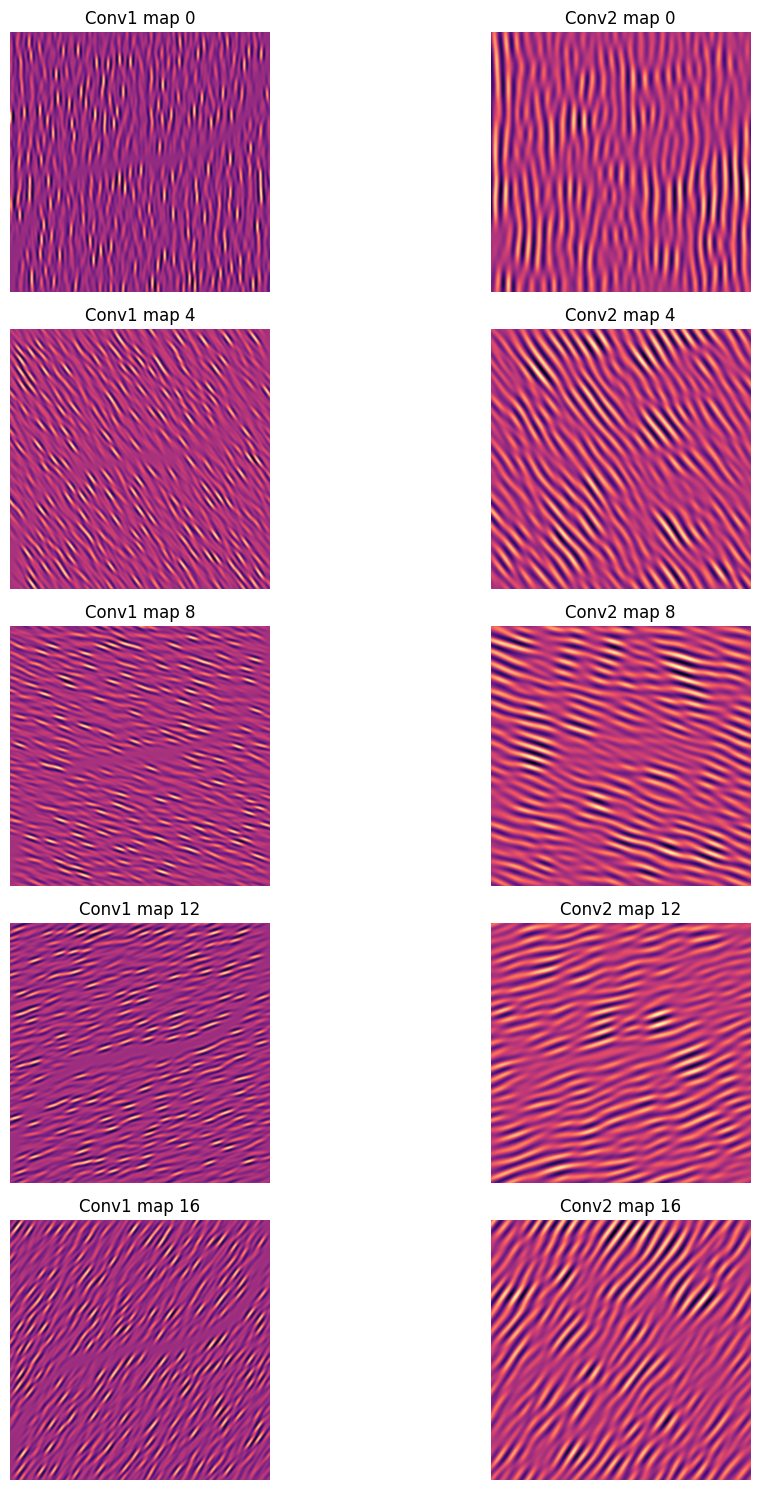

In [ ]:
# Remove batch dimension: (20, H, W)
feature_maps1 = conv2.squeeze(0)
feature_maps2 = conv3.squeeze(0)

# Pick every 4th map
indices_to_show = list(range(0, feature_maps1.shape[0], 4))
num = len(indices_to_show)

plt.figure(figsize=(12, 3 * num))

for i, idx in enumerate(indices_to_show):
    # First convolution on the left
    plt.subplot(num, 2, 2*i + 1)
    plt.imshow(feature_maps1[idx].detach().cpu().numpy(),origin= "lower", cmap='magma')
    plt.title(f"Conv1 map {idx}")
    plt.axis('off')
    
    # Second convolution on the right
    plt.subplot(num, 2, 2*i + 2)
    plt.imshow(feature_maps2[idx].detach().cpu().numpy(), origin= "lower", cmap='magma')
    plt.title(f"Conv2 map {idx}") 
    plt.axis('off')

plt.tight_layout()
plt.show()